In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick
import seaborn as sns

file_id = '1ewIyvaTB1T_BVNM5CYNTXrIpPv9kJjK3'   # new file
url = f"https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t"

# load data
loan_df = pd.read_csv(url)
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2255820 entries, 0 to 2255819
Data columns (total 61 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   loan_amnt                   int64  
 1   term                        int64  
 2   int_rate                    float64
 3   installment                 float64
 4   sub_grade                   object 
 5   emp_title                   object 
 6   emp_length                  float64
 7   home_ownership              object 
 8   annual_inc                  float64
 9   verification_status         object 
 10  loan_status                 object 
 11  purpose                     object 
 12  addr_state                  object 
 13  dti                         float64
 14  delinq_2yrs                 float64
 15  inq_last_6mths              float64
 16  open_acc                    float64
 17  pub_rec                     float64
 18  revol_bal                   int64  
 19  revol_util           

In [18]:
# Drop same high-cardinality / redundant columns as LR notebook
loan_df = loan_df.drop(columns=['emp_title', 'addr_state'])

# Binary target — same mapping as LR
loan_df = loan_df[loan_df['loan_status'].isin([
    'Fully Paid', 'Charged Off', 'Default',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'
])]

loan_df['loan_status'] = loan_df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1
})

print(f"Shape after filtering: {loan_df.shape}")
print(f"Class distribution:\n{loan_df['loan_status'].value_counts()}")
print(f"Default rate: {loan_df['loan_status'].mean():.2%}")

Shape after filtering: (1303886, 59)
Class distribution:
loan_status
0    1042005
1     261881
Name: count, dtype: int64
Default rate: 20.08%


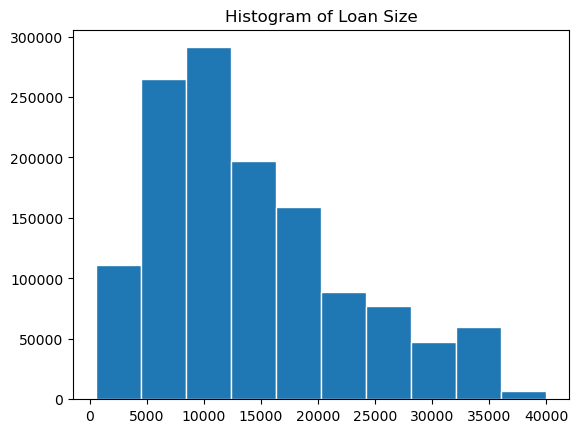

In [32]:
plt.hist(loan_df['loan_amnt'], edgecolor='white')
plt.title("Histogram of Loan Size")
plt.show()

### Compare Default rate for different loan sizes and terms

In [20]:
loan_df['term'].unique()

array([36, 60], dtype=int64)

In [29]:

# Define default: adjust these values based on your loan_status categories
default_statuses = [1]

loan_df['is_default'] = loan_df['loan_status'].isin(default_statuses).astype(int)

# Bin loan amounts into $5K increments
bins = list(range(0, 45000, 5000))
labels = [f'${b//1000}K-{(b+5000)//1000}K' for b in bins[:-1]]
loan_df['loan_bin'] = pd.cut(loan_df['loan_amnt'], bins=bins, labels=labels)

# Compute default rate by bin and term
result = (loan_df.groupby(['loan_bin', 'term'])['is_default']
            .mean()
            .unstack('term')
            .round(4) * 100)

print(result)

# Optional: chi-square test per bin
from scipy.stats import chi2_contingency

for bin_label in labels:
    subset = loan_df[loan_df['loan_bin'] == bin_label]
    ct = pd.crosstab(subset['term'], subset['is_default'])
    if ct.shape == (2, 2):
        chi2, p, _, _ = chi2_contingency(ct)
        print(f'{bin_label}: chi2={chi2:.1f}, p={p:.4f}')

C:\Users\HP\AppData\Local\Temp\ipykernel_27912\3749916320.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = (loan_df.groupby(['loan_bin', 'term'])['is_default']


term         36     60
loan_bin              
$0K-5K    15.88  23.23
$5K-10K   16.61  30.85
$10K-15K  15.56  33.48
$15K-20K  16.05  33.37
$20K-25K  14.50  32.55
$25K-30K  15.83  31.42
$30K-35K  19.08  31.94
$35K-40K  15.22  25.66
$0K-5K: chi2=79.6, p=0.0000
$5K-10K: chi2=2430.6, p=0.0000
$10K-15K: chi2=11165.7, p=0.0000
$15K-20K: chi2=8410.6, p=0.0000
$20K-25K: chi2=5936.0, p=0.0000
$25K-30K: chi2=2542.4, p=0.0000
$30K-35K: chi2=1528.7, p=0.0000
$35K-40K: chi2=141.9, p=0.0000


In [ ]:
# create bins for 30 and 60-month term
bins = result.index.astype(str)
term_36 = result[36].values
term_60 = result[60].values

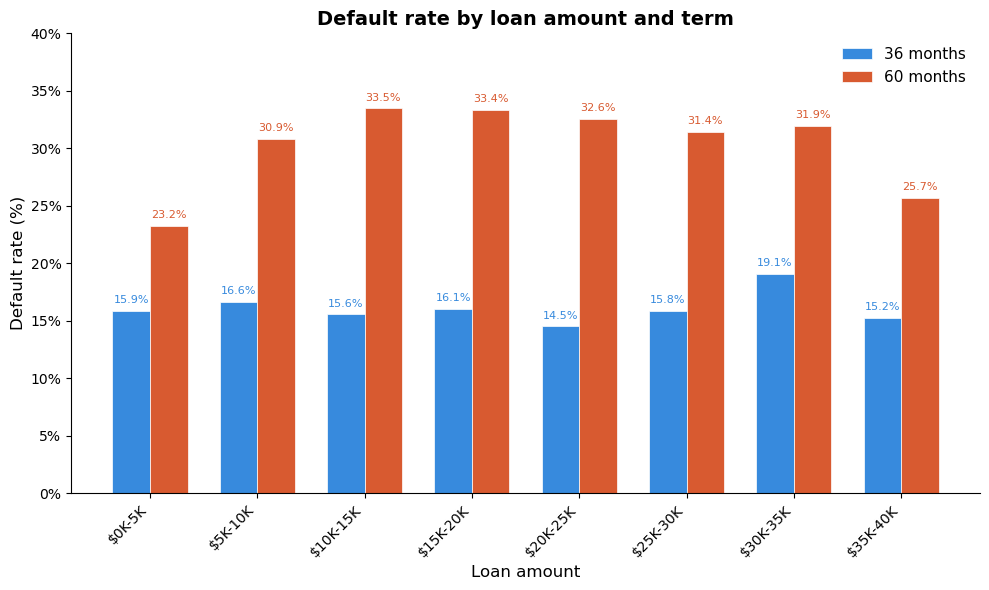

In [ ]:
# barchart comparing 30 and 60-month term
x = np.arange(len(bins))
width = 0.35
 
fig, ax = plt.subplots(figsize=(10, 6))
 
bars_36 = ax.bar(x - width/2, term_36, width, label='36 months',
                 color='#378ADD', edgecolor='white', linewidth=0.5)
bars_60 = ax.bar(x + width/2, term_60, width, label='60 months',
                 color='#D85A30', edgecolor='white', linewidth=0.5)
 
# Add value labels on top of each bar
for bar in bars_36:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontsize=8, color='#378ADD')
 
for bar in bars_60:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontsize=8, color='#D85A30')
 
# Labels and formatting
ax.set_xlabel('Loan amount', fontsize=12)
ax.set_ylabel('Default rate (%)', fontsize=12)
ax.set_title('Default rate by loan amount and term', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bins, rotation=45, ha='right')
ax.set_ylim(0, 40)
ax.legend(frameon=False, fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
 
plt.tight_layout()
plt.savefig('default_rate_by_term.png', dpi=300, bbox_inches='tight')
plt.show()

### Heatmaps comparing default rate for different loan sizes, interest rates, and terms

In [ ]:
# find maximum rate
loan_df['int_rate'].max()

30.99

C:\Users\HP\AppData\Local\Temp\ipykernel_27912\3522921168.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = (loan_df.groupby(['loan_bin', 'rate_bin', 'term'])['is_default']


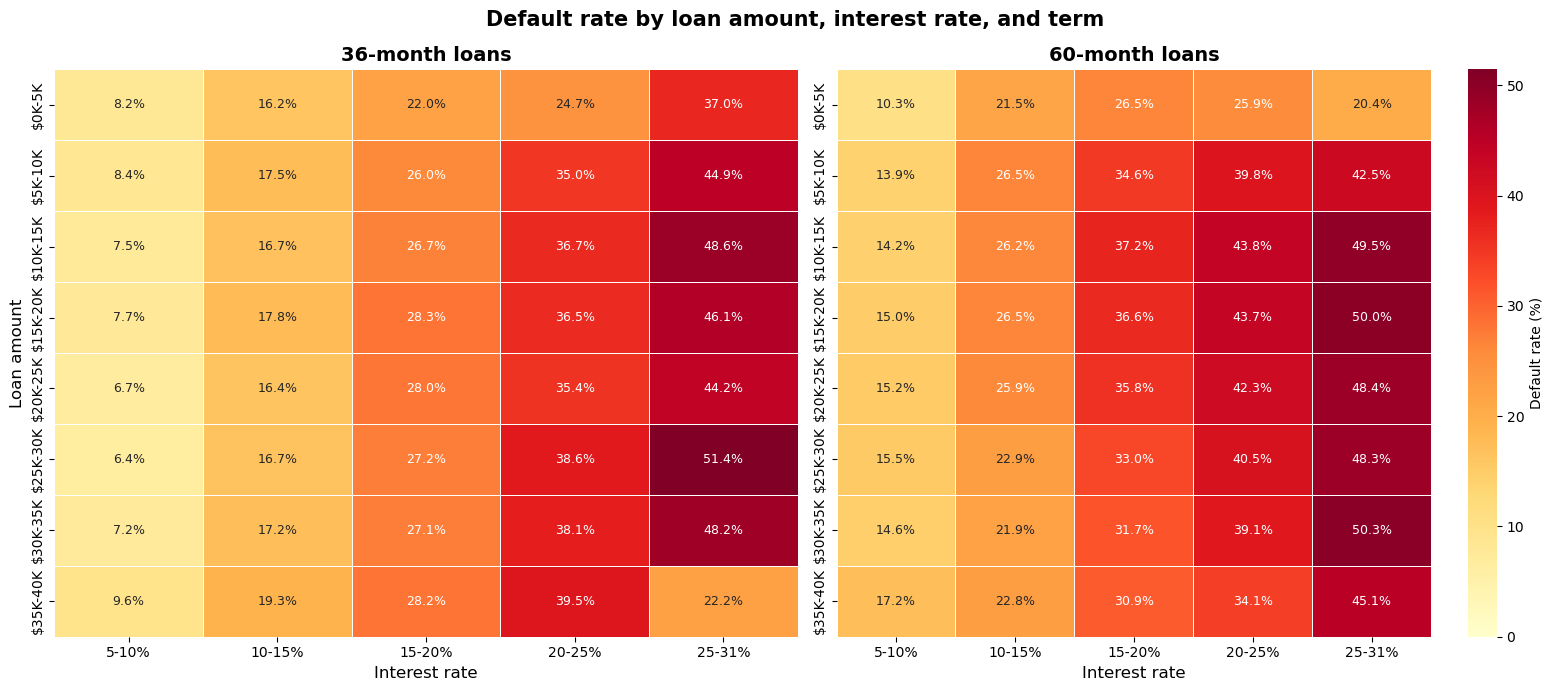

In [ ]:
# 1. BIN INTEREST RATE
rate_bins = [5, 10, 15, 20, 25, 31]
rate_labels = ['5-10%', '10-15%', '15-20%', '20-25%', '25-31%']
loan_df['rate_bin'] = pd.cut(loan_df['int_rate'], bins=rate_bins, labels=rate_labels)


# 2. COMPUTE DEFAULT RATE BY LOAN BIN × RATE BIN × TERM
result = (loan_df.groupby(['loan_bin', 'rate_bin', 'term'])['is_default']
            .mean()
            .round(4) * 100)

heatmap_36 = result.xs(36, level='term').unstack('rate_bin')
heatmap_60 = result.xs(60, level='term').unstack('rate_bin')

# Drop any fully-empty rows/columns so the heatmap isn't sparse
heatmap_36 = heatmap_36.dropna(how='all', axis=0).dropna(how='all', axis=1)
heatmap_60 = heatmap_60.dropna(how='all', axis=0).dropna(how='all', axis=1)


# 3. PLOT SIDE-BY-SIDE HEATMAPS (seaborn handles labels natively)
vmin = 0
vmax = max(heatmap_36.max().max(), heatmap_60.max().max())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title, show_cbar in zip(
        axes,
        [heatmap_36, heatmap_60],
        ['36-month loans', '60-month loans'],
        [False, True]):                        # colorbar on right panel only

    sns.heatmap(data,
                ax=ax,
                annot=True,               # show values in cells
                fmt='.1f',                # one decimal place
                cmap='YlOrRd',
                vmin=vmin, vmax=vmax,
                linewidths=0.5,           # thin grid lines between cells
                linecolor='white',
                cbar=show_cbar,
                cbar_kws={'label': 'Default rate (%)'} if show_cbar else {},
                annot_kws={'fontsize': 9})

    # Add '%' to annotations (seaborn annot doesn't support suffix)
    for t in ax.texts:
        t.set_text(t.get_text() + '%')

    ax.set_xlabel('Interest rate', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)

axes[0].set_ylabel('Loan amount', fontsize=12)

fig.suptitle('Default rate by loan amount, interest rate, and term',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('default_rate_heatmap_by_term.png', dpi=300, bbox_inches='tight')
plt.show()